In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded ✅")

Libraries loaded ✅


In [4]:
users        = pd.read_csv('../data/raw/users.csv')
courses      = pd.read_csv('../data/raw/courses.csv')
transactions = pd.read_csv('../data/raw/transactions.csv')

print(f"Users:        {users.shape}")
print(f"Courses:      {courses.shape}")
print(f"Transactions: {transactions.shape}")


Users:        (500, 4)
Courses:      (50, 5)
Transactions: (1000, 5)


In [9]:
print("=== USERS ===")
display(users.head())
display(users.info())
display(users.describe())

print("=== COURSES ===")
display(courses.head())
display(courses.info())

print("=== TRANSACTIONS ===")
display(transactions.head())
display(transactions.info())

=== USERS ===


,UserID,Age,Gender,Country
0,1,56,Male,Canada
1,2,46,Female,India
2,3,32,Male,Canada
3,4,25,Male,USA
4,5,38,Male,UK


<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   UserID   500 non-null    int64
 1   Age      500 non-null    int64
 2   Gender   500 non-null    str  
 3   Country  500 non-null    str  
dtypes: int64(2), str(2)
memory usage: 15.8 KB


None

,UserID,Age
count,500.000000,500.000000
mean,250.500000,39.326000
std,144.481833,12.200386
min,1.000000,18.000000
25%,125.750000,29.000000
50%,250.500000,41.000000
75%,375.250000,50.000000
max,500.000000,59.000000


...

None

=== TRANSACTIONS ===


,TransactionID,UserID,CourseID,Amount,TransactionDate
0,1,493,9,3097,2023-01-01 00:00:00
1,2,426,15,641,2023-01-01 08:00:00
2,3,108,10,3159,2023-01-01 16:00:00
3,4,382,24,1339,2023-01-02 00:00:00
4,5,450,42,4118,2023-01-02 08:00:00


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   TransactionID    1000 non-null   int64
 1   UserID           1000 non-null   int64
 2   CourseID         1000 non-null   int64
 3   Amount           1000 non-null   int64
 4   TransactionDate  1000 non-null   str  
dtypes: int64(4), str(1)
memory usage: 39.2 KB


None

In [6]:
print("NULL VALUES:")
print(users.isnull().sum())
print(courses.isnull().sum())
print(transactions.isnull().sum())

print("\nDUPLICATES:")
print(f"Users:        {users.duplicated().sum()}")
print(f"Courses:      {courses.duplicated().sum()}")
print(f"Transactions: {transactions.duplicated().sum()}")

NULL VALUES:
UserID     0
Age        0
Gender     0
Country    0
dtype: int64
CourseID          0
CourseCategory    0
CourseLevel       0
CourseRating      0
CoursePrice       0
dtype: int64
TransactionID      0
UserID             0
CourseID           0
Amount             0
TransactionDate    0
dtype: int64

DUPLICATES:
Users:        0
Courses:      0
Transactions: 0


In [7]:
print(f"Total Revenue:     ${transactions['Amount'].sum():,.2f}")
print(f"Avg Spend/User:    ${transactions.groupby('UserID')['Amount'].sum().mean():,.2f}")
print(f"Avg Courses/User:  {transactions.groupby('UserID')['CourseID'].count().mean():.1f}")
print(f"Most Popular Cat:  {transactions.merge(courses)['CourseCategory'].mode()[0]}")


Total Revenue:     $2,833,155.00
Avg Spend/User:    $6,528.01
Avg Courses/User:  2.3
Most Popular Cat:  Design


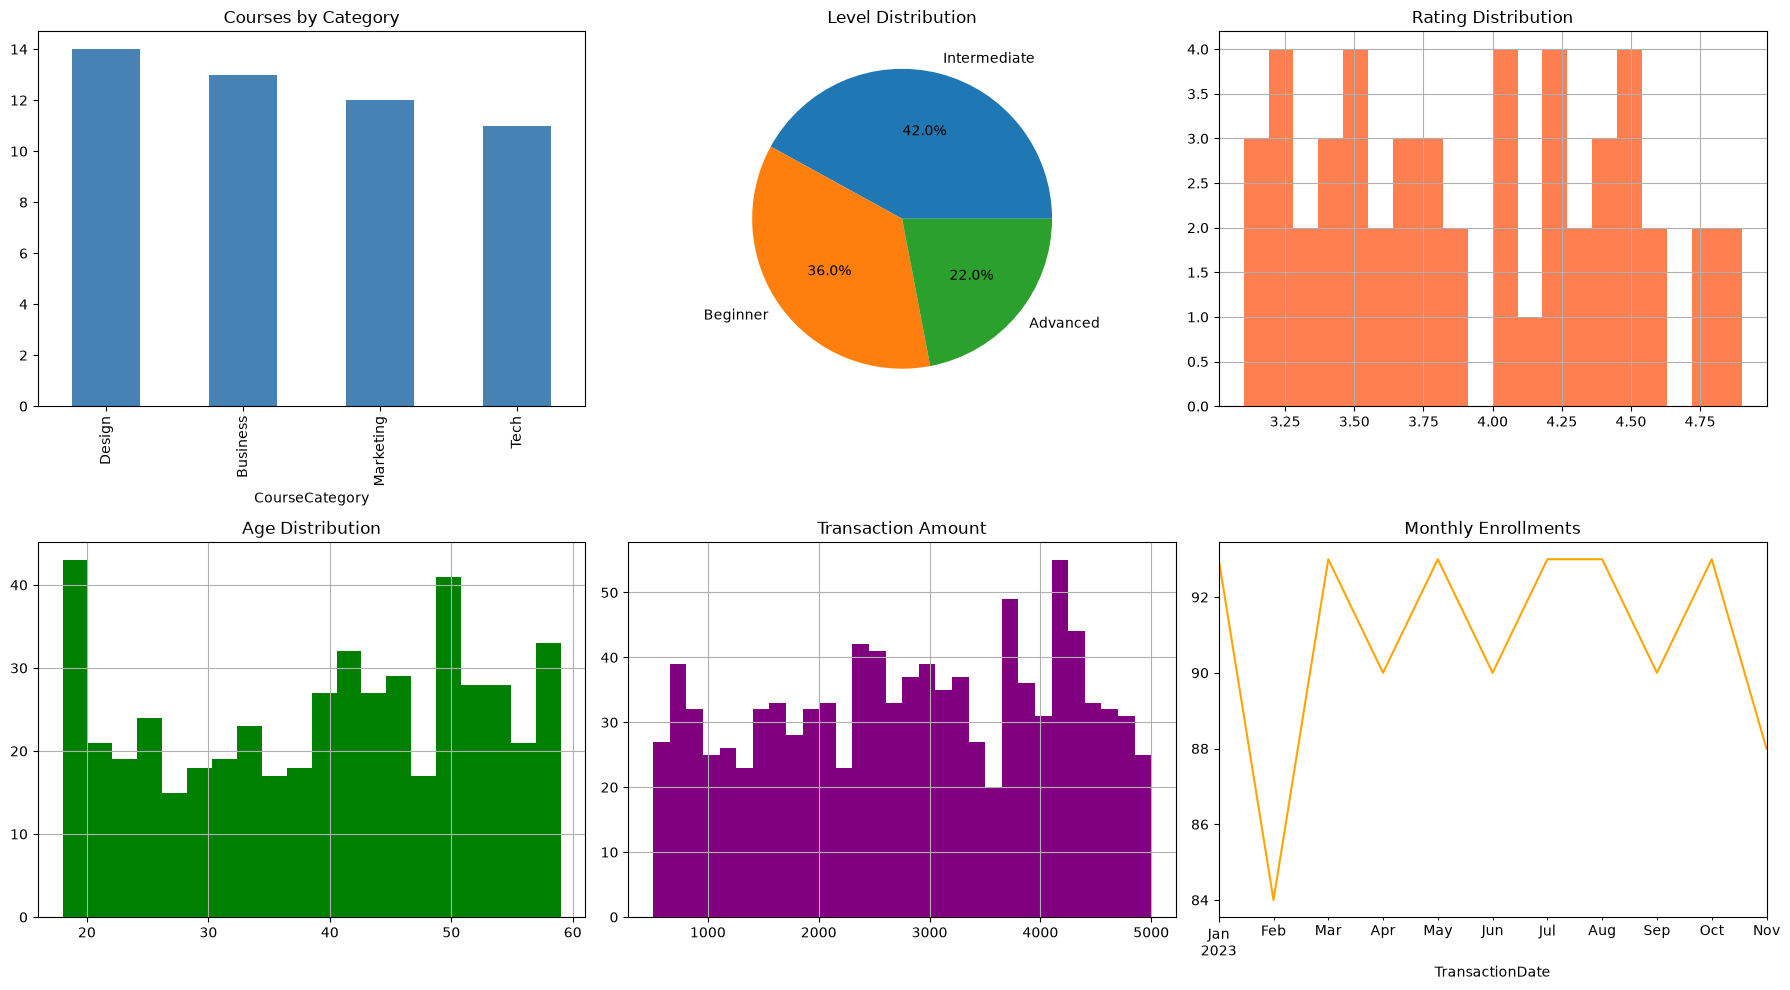

Saved to reports/figures/ ✅


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Plot 1 - Course category distribution
courses['CourseCategory'].value_counts().plot(
    kind='bar', ax=axes[0,0], color='steelblue'
)
axes[0,0].set_title('Courses by Category')

# Plot 2 - Course level distribution
courses['CourseLevel'].value_counts().plot(
    kind='pie', ax=axes[0,1], autopct='%1.1f%%'
)
axes[0,1].set_title('Level Distribution')

# Plot 3 - Rating distribution
courses['CourseRating'].hist(
    ax=axes[0,2], bins=20, color='coral'
)
axes[0,2].set_title('Rating Distribution')

# Plot 4 - Age distribution of users
users['Age'].hist(
    ax=axes[1,0], bins=20, color='green'
)
axes[1,0].set_title('Age Distribution')

# Plot 5 - Spending distribution
transactions['Amount'].hist(
    ax=axes[1,1], bins=30, color='purple'
)
axes[1,1].set_title('Transaction Amount')

# Plot 6 - Enrollments over time
transactions['TransactionDate'] = pd.to_datetime(transactions['TransactionDate'])
transactions.set_index('TransactionDate').resample('ME')['CourseID'].count().plot(
    ax=axes[1,2], color='orange'
)
axes[1,2].set_title('Monthly Enrollments')

plt.tight_layout()
import os
os.makedirs('../reports/figures', exist_ok=True)
plt.savefig('../reports/figures/01_eda_overview.png', dpi=150)
plt.show()
print("Saved to reports/figures/ ✅")